# Paper Plots - UMAP Scatter (MEL)

This notebook generates publication-ready scatter plots for the five legal targets:

- Relevance
- Interpretability
- Completeness
- Differential Regime
- Discretionality

All figures are exported in **PNG** (high DPI), **SVG** (vector), and **PDF**, and the pipeline is designed to be easy to edit and fully reproducible.

## 1) Imports and Plot Style

This cell defines a clean style suitable for paper figures. Modify here if your journal requests a specific format.

In [51]:
from __future__ import annotations

from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.titlesize": 21,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
})



## 2) Configuration (Editable)

These are the only knobs you usually need to change.

In [52]:
PROJECT_ROOT = Path.cwd()

CANDIDATE_DATA_DIRS = [
    PROJECT_ROOT / "Scatter mel umap",
    PROJECT_ROOT / "Version 2" / "Scatter mel umap",
    PROJECT_ROOT.parent / "Version 2" / "Scatter mel umap",
]

DATA_DIR = next((path.resolve() for path in CANDIDATE_DATA_DIRS if path.exists()), CANDIDATE_DATA_DIRS[0].resolve())
OUTPUT_DIR = DATA_DIR.parent / "paper_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_FILES = {
    "Relevance": "scatter_data__Relevance.csv",
    "Interpretability": "scatter_data__Interpretability.csv",
    "Completeness": "scatter_data__Completeness.csv",
    "Differential Regime": "scatter_data__Differential_Regime.csv",
    "Discretionality": "scatter_data__Discretionality.csv",
}

REQUIRED_COLUMNS = {"Law", "Article", "umap_x", "umap_y", "target_value"}

POINT_SIZE = 56
ALPHA = 0.90
FIGSIZE_SINGLE = (6.6, 5.0)
EXPORT_DPI = 400

TITLE_FONT_SIZE = 21
AXIS_LABEL_FONT_SIZE = 16
PANEL_AXIS_LABEL_FONT_SIZE = 13
TICK_LABEL_FONT_SIZE = 15
LEGEND_FONT_SIZE = 14
LEGEND_TITLE_FONT_SIZE = 14

TARGET_TITLE_PREFIX = {
    "Relevance": "a",
    "Interpretability": "b",
    "Completeness": "c",
    "Differential Regime": "d",
    "Discretionality": "e",
}

TARGET_DISPLAY_NAME = {
    "Interpretability": "Interpretation",
    "Discretionality": "Discretion",
}

def format_target_title(target_name: str) -> str:
    prefix = TARGET_TITLE_PREFIX.get(target_name)
    display_name = TARGET_DISPLAY_NAME.get(target_name, target_name)
    return f"{prefix}) {display_name}" if prefix else display_name

# Color palettes by target value. Update freely.
PALETTE_BY_TARGET = {
    "Relevance": {0: "#9E9E9E", 1: "#1B9E77"},
    "Completeness": {0: "#9E9E9E", 1: "#1B9E77"},
    "Differential Regime": {0: "#9E9E9E", 1: "#1B9E77"},
    "Discretionality": {0: "#9E9E9E", 1: "#1B9E77"},
    "Interpretability": {1: "#7A5195", 2: "#EF5675", 3: "#FFA600"},
}

FALLBACK_COLORS = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#B279A2"]


def resolve_scatter_file(file_name: str) -> Path:
    candidates = [
        DATA_DIR / file_name,
        PROJECT_ROOT / file_name,
        PROJECT_ROOT / "Scatter mel umap" / file_name,
        PROJECT_ROOT / "Version 2" / "Scatter mel umap" / file_name,
        PROJECT_ROOT.parent / "Version 2" / "Scatter mel umap" / file_name,
    ]

    seen = set()
    unique_candidates = []
    for c in candidates:
        s = str(c)
        if s not in seen:
            seen.add(s)
            unique_candidates.append(c)

    for candidate in unique_candidates:
        if candidate.exists():
            return candidate.resolve()

    tried = "\n- ".join(str(c) for c in unique_candidates)
    raise FileNotFoundError(f"Missing file: {file_name}\nTried:\n- {tried}")


print("CWD:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)








CWD: c:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2
DATA_DIR: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\Scatter mel umap
OUTPUT_DIR: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures


## 3) Utility Functions

Validation + plotting functions to keep the workflow robust and maintainable.

In [53]:
def load_scatter_data(target_name: str, file_name: str) -> pd.DataFrame:
    path = resolve_scatter_file(file_name)

    df = pd.read_csv(path)
    missing = REQUIRED_COLUMNS - set(df.columns)
    if missing:
        raise ValueError(f"{file_name} is missing required columns: {sorted(missing)}")

    df = df.copy()
    if "target" not in df.columns:
        df["target"] = target_name
    else:
        df["target"] = df["target"].fillna(target_name)

    df["target_value"] = pd.to_numeric(df["target_value"], errors="coerce")
    df = df.dropna(subset=["umap_x", "umap_y", "target_value"]).copy()
    df["target_value"] = df["target_value"].astype(int)
    df["target_display"] = target_name
    return df


def get_palette(target_name: str, present_values: list[int]) -> dict[int, str]:
    configured = PALETTE_BY_TARGET.get(target_name, {})
    palette = {}
    for i, v in enumerate(sorted(present_values)):
        palette[v] = configured.get(v, FALLBACK_COLORS[i % len(FALLBACK_COLORS)])
    return palette


def format_class_label(target_name: str, value: int) -> str:
    # For binary targets, display boolean labels in the legend.
    if target_name != "Interpretability" and value in (0, 1):
        return "False" if value == 0 else "True"

    # Interpretability scale labels for paper readability.
    if target_name == "Interpretability":
        mapping = {
            3: "High (3)",
            2: "Medium (2)",
            1: "Low (1)",
        }
        return mapping.get(value, str(value))

    return str(value)


def plot_target_scatter(
    df: pd.DataFrame,
    target_name: str,
    ax: plt.Axes,
    point_size: int = POINT_SIZE,
    alpha: float = ALPHA,
    legend_loc: str = "best",
    axis_label_font_size: int = AXIS_LABEL_FONT_SIZE,
) -> dict[int, str]:
    if target_name == "Interpretability":
        values = sorted(df["target_value"].unique().tolist(), reverse=True)
    else:
        values = sorted(df["target_value"].unique().tolist())

    palette = get_palette(target_name, values)

    for value in values:
        subset = df[df["target_value"] == value]
        ax.scatter(
            subset["umap_x"],
            subset["umap_y"],
            s=point_size,
            alpha=alpha,
            c=palette[value],
            edgecolors="white",
            linewidths=0.45,
            label=format_class_label(target_name, value),
        )

    ax.set_title(format_target_title(target_name), fontsize=TITLE_FONT_SIZE, pad=10)
    ax.set_xlabel("UMAP 1", fontsize=axis_label_font_size)
    ax.set_ylabel("UMAP 2", fontsize=axis_label_font_size)
    ax.grid(alpha=0.20, linestyle="--", linewidth=0.5)
    ax.tick_params(axis="both", labelsize=TICK_LABEL_FONT_SIZE)

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            label=format_class_label(target_name, v),
            markerfacecolor=palette[v],
            markeredgecolor="white",
            markeredgewidth=0.45,
            markersize=7,
        )
        for v in values
    ]
    ax.legend(
        handles=legend_handles,
        frameon=False,
        loc=legend_loc,
        fontsize=LEGEND_FONT_SIZE,
    )
    return palette


def save_figure(fig: plt.Figure, stem: str) -> tuple[Path, Path, Path]:
    png_path = OUTPUT_DIR / f"{stem}.png"
    svg_path = OUTPUT_DIR / f"{stem}.svg"
    pdf_path = OUTPUT_DIR / f"{stem}.pdf"

    fig.savefig(png_path, dpi=EXPORT_DPI, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    return png_path, svg_path, pdf_path





## 4) Generate and Export Individual Scatter Plots

One figure per target. Exports are saved to `Version 2/paper_figures`.

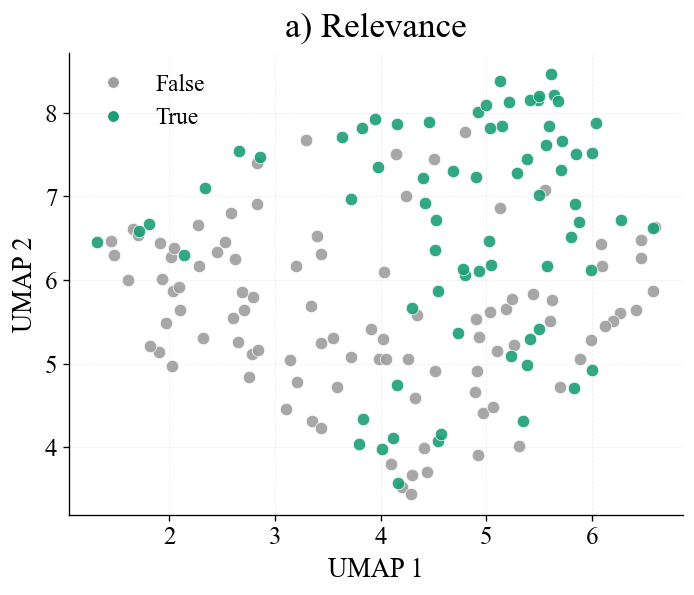

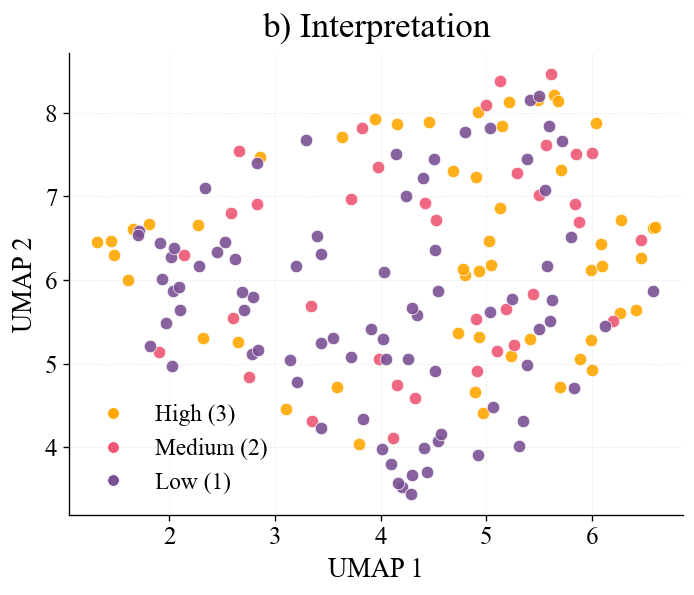

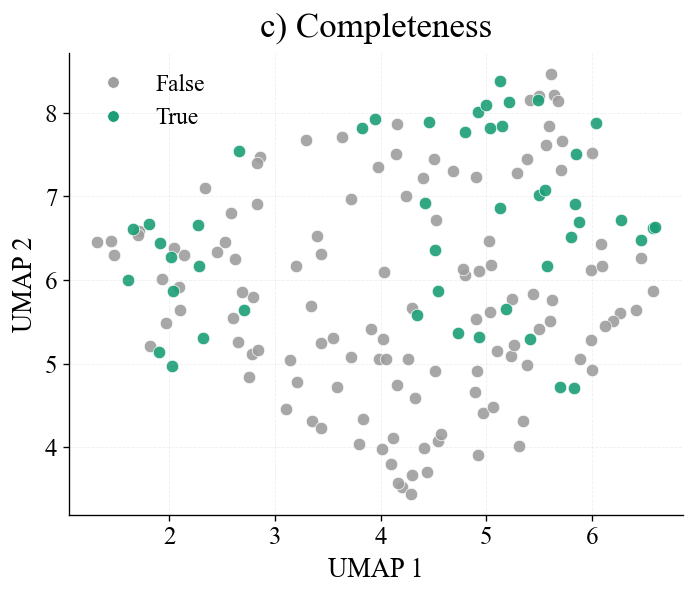

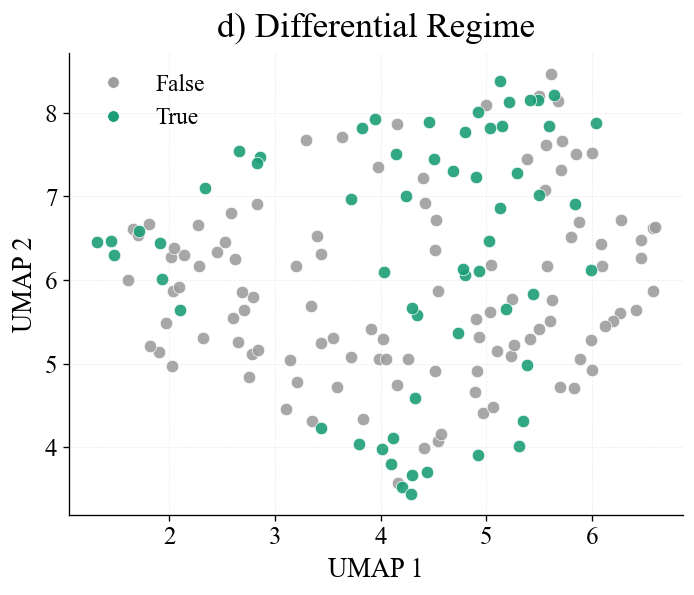

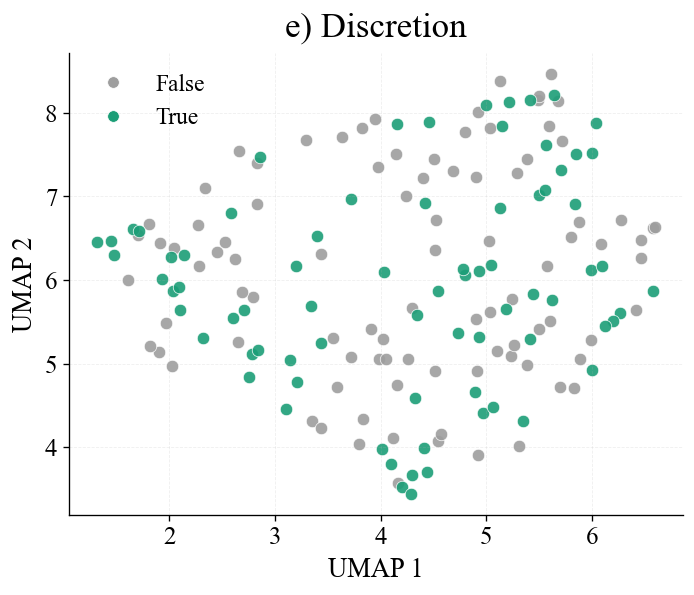

,target,rows,classes,png,svg,pdf
0,Relevance,169,"{0: 97, 1: 72}",C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
1,Interpretability,169,"{1: 81, 2: 36, 3: 52}",C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
2,Completeness,169,"{0: 122, 1: 47}",C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
3,Differential Regime,169,"{0: 109, 1: 60}",C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
4,Discretionality,169,"{0: 93, 1: 76}",C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...


In [54]:
all_data = {}
export_rows = []

# Early check: fail fast with a clear path error before plotting.
for file_name in TARGET_FILES.values():
    _ = resolve_scatter_file(file_name)

for target_name, file_name in TARGET_FILES.items():
    df_target = load_scatter_data(target_name, file_name)
    all_data[target_name] = df_target

    fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
    _ = plot_target_scatter(df_target, target_name, ax=ax)

    stem = f"paper_scatter_mel_umap__{target_name.lower().replace(' ', '_')}"
    png_path, svg_path, pdf_path = save_figure(fig, stem)
    plt.show()
    plt.close(fig)

    counts = df_target["target_value"].value_counts().sort_index().to_dict()
    export_rows.append({
        "target": target_name,
        "rows": len(df_target),
        "classes": str(counts),
        "png": str(png_path),
        "svg": str(svg_path),
        "pdf": str(pdf_path),
    })

export_log = pd.DataFrame(export_rows)
export_log




## 5) Multi-Panel Figure (5 Targets)

Optional compact panel for appendix/slides or paper drafts.

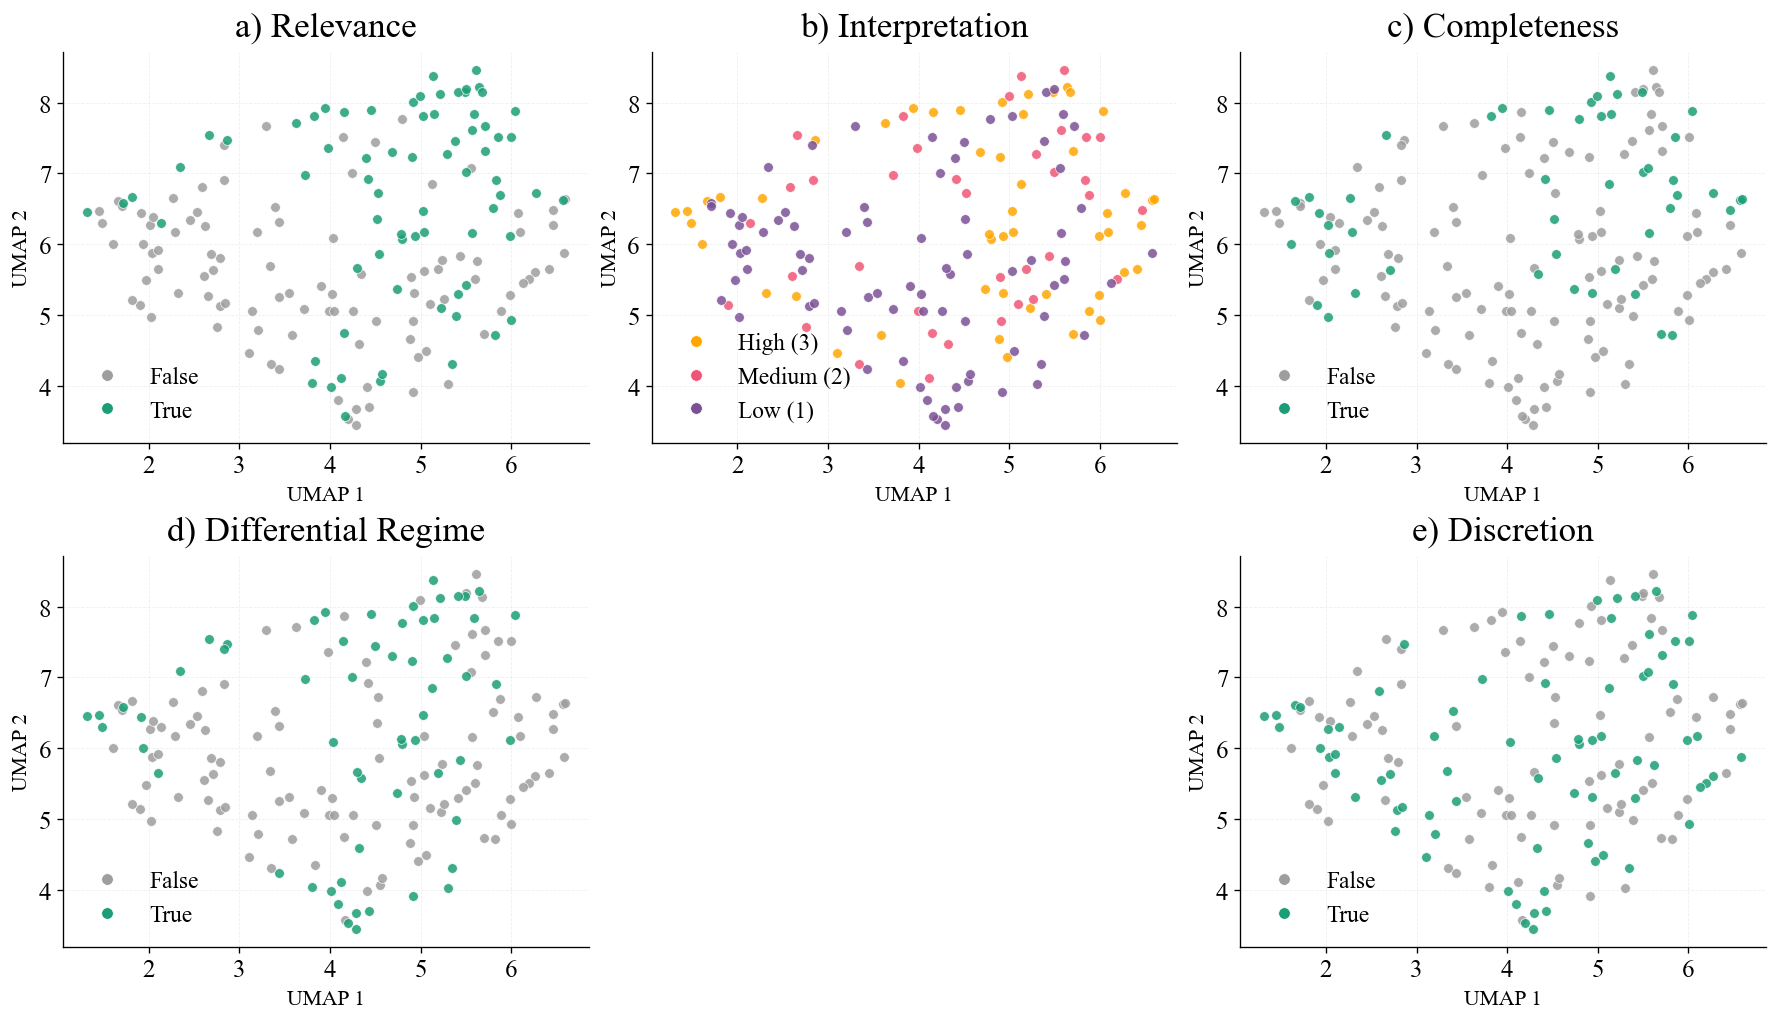

Saved panel:
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\paper_scatter_mel_umap__panel_5_targets.png
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\paper_scatter_mel_umap__panel_5_targets.svg
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\paper_scatter_mel_umap__panel_5_targets.pdf


In [55]:
n_targets = len(TARGET_FILES)
ncols = 3
nrows = math.ceil(n_targets / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.9, nrows * 4.2), constrained_layout=True)
axes = axes.flatten()

# Custom layout for 5 targets:
# Top row: 3 targets, bottom row: left and right occupied, center empty.
ordered_targets = list(TARGET_FILES.keys())
if len(ordered_targets) == 5 and len(axes) >= 6:
    slot_map = [0, 1, 2, 3, 5]  # leave index 4 (bottom-center) empty
    for target_name, slot in zip(ordered_targets, slot_map):
        plot_target_scatter(
            all_data[target_name],
            target_name,
            ax=axes[slot],
            point_size=34,
            alpha=0.85,
            legend_loc="lower left",
            axis_label_font_size=PANEL_AXIS_LABEL_FONT_SIZE,
        )

    axes[4].axis("off")
else:
    for ax, target_name in zip(axes, ordered_targets):
        plot_target_scatter(
            all_data[target_name],
            target_name,
            ax=ax,
            point_size=34,
            alpha=0.85,
            legend_loc="lower left",
            axis_label_font_size=PANEL_AXIS_LABEL_FONT_SIZE,
        )

    for i in range(len(ordered_targets), len(axes)):
        axes[i].axis("off")

panel_png, panel_svg, panel_pdf = save_figure(fig, "paper_scatter_mel_umap__panel_5_targets")
plt.show()
plt.close(fig)

print("Saved panel:")
print("-", panel_png)
print("-", panel_svg)
print("-", panel_pdf)







## 6) Reproducibility Log

Exports a traceable CSV with sources and outputs.

In [56]:
repro_log = export_log.copy()
repro_log["source_file"] = repro_log["target"].map(TARGET_FILES)
repro_log["source_path"] = repro_log["source_file"].apply(lambda x: str(resolve_scatter_file(x)))

log_path = OUTPUT_DIR / "paper_scatter_export_log.csv"
repro_log.to_csv(log_path, index=False)

print("Saved reproducibility log:", log_path)
repro_log



Saved reproducibility log: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\paper_scatter_export_log.csv


,target,rows,classes,png,svg,pdf,source_file,source_path
0,Relevance,169,"{0: 97, 1: 72}",C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,scatter_data__Relevance.csv,C:\Users\57305\OneDrive - Universidad Nacional...
1,Interpretability,169,"{1: 81, 2: 36, 3: 52}",C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,scatter_data__Interpretability.csv,C:\Users\57305\OneDrive - Universidad Nacional...
2,Completeness,169,"{0: 122, 1: 47}",C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,scatter_data__Completeness.csv,C:\Users\57305\OneDrive - Universidad Nacional...
3,Differential Regime,169,"{0: 109, 1: 60}",C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,scatter_data__Differential_Regime.csv,C:\Users\57305\OneDrive - Universidad Nacional...
4,Discretionality,169,"{0: 93, 1: 76}",C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,scatter_data__Discretionality.csv,C:\Users\57305\OneDrive - Universidad Nacional...


## 7) Gray Rule Scatter (Special Figure)

This section reproduces `scatter_mel_umap__gray_rule_allbin0_or_interp1` with the same visual style as the paper figures,
and exports two versions: **with title** and **without title** (PNG, SVG, PDF).


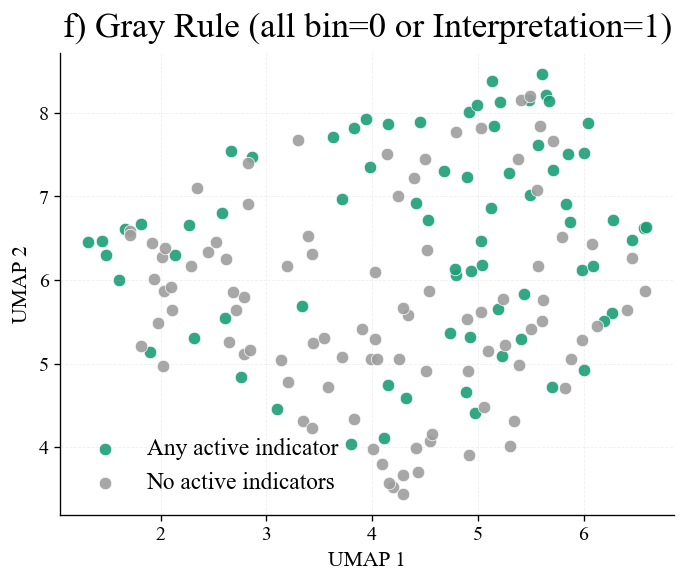

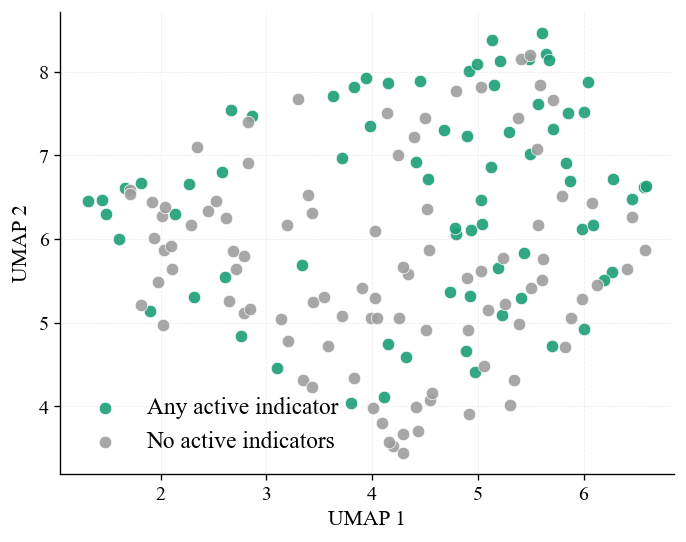

,variant,png,svg,pdf
0,with_title,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
1,without_title,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...


In [57]:
GRAY_RULE_FILE = "scatter_data__gray_rule_allbin0_or_interp1.csv"
GRAY_RULE_AXIS_LABEL_FONT_SIZE = 13
GRAY_RULE_TICK_LABEL_FONT_SIZE = 12

def load_gray_rule_data(file_name: str = GRAY_RULE_FILE) -> pd.DataFrame:
    path = resolve_scatter_file(file_name)
    df = pd.read_csv(path).copy()

    required = {"umap_x", "umap_y", "color_group"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{file_name} is missing required columns: {sorted(missing)}")

    df["color_group"] = df["color_group"].astype(str).str.strip().str.lower()
    valid_groups = {"color", "grey"}
    df = df[df["color_group"].isin(valid_groups)].copy()
    return df


def plot_gray_rule_scatter(
    df: pd.DataFrame,
    ax: plt.Axes,
    show_title: bool = True,
    legend_loc: str = "lower left",
    axis_label_font_size: int = GRAY_RULE_AXIS_LABEL_FONT_SIZE,
) -> None:
    green = PALETTE_BY_TARGET["Relevance"][1]
    gray = PALETTE_BY_TARGET["Relevance"][0]

    color_map = {
        "color": green,
        "grey": gray,
    }
    label_map = {
        "color": "Any active indicator",
        "grey": "No active indicators",
    }

    group_order = ["color", "grey"]
    for group in group_order:
        subset = df[df["color_group"] == group]
        if subset.empty:
            continue
        ax.scatter(
            subset["umap_x"],
            subset["umap_y"],
            s=POINT_SIZE,
            alpha=ALPHA,
            c=color_map[group],
            edgecolors="white",
            linewidths=0.45,
            label=label_map[group],
        )

    if show_title:
        ax.set_title("f) Gray Rule (all bin=0 or Interpretation=1)", fontsize=TITLE_FONT_SIZE, pad=10)
    else:
        ax.set_title("")

    ax.set_xlabel("UMAP 1", fontsize=axis_label_font_size)
    ax.set_ylabel("UMAP 2", fontsize=axis_label_font_size)
    ax.grid(alpha=0.20, linestyle="--", linewidth=0.5)
    ax.tick_params(axis="both", labelsize=GRAY_RULE_TICK_LABEL_FONT_SIZE)
    ax.legend(frameon=False, loc=legend_loc, fontsize=LEGEND_FONT_SIZE)


gray_df = load_gray_rule_data()

gray_exports = []
for suffix, show_title in [("with_title", True), ("without_title", False)]:
    fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
    plot_gray_rule_scatter(gray_df, ax=ax, show_title=show_title)

    stem = f"paper_scatter_mel_umap__gray_rule_allbin0_or_interp1__{suffix}"
    png_path, svg_path, pdf_path = save_figure(fig, stem)
    plt.show()
    plt.close(fig)

    gray_exports.append({
        "variant": suffix,
        "png": str(png_path),
        "svg": str(svg_path),
        "pdf": str(pdf_path),
    })

pd.DataFrame(gray_exports)


